# 02 — Seaborn: visualización analítica aplicada a cartera de seguros

Este notebook desarrolla visualizaciones estadísticas con Seaborn: distribuciones, comparaciones, relaciones, correlaciones y tendencias.

**Objetivo:** elegir la gráfica adecuada según la pregunta de negocio y mejorar la calidad estética de las visualizaciones.

In [66]:
# Importamos las librerías necesarias para análisis tabular y visualización.
# Path construye rutas de archivo de forma portable.
# pandas y NumPy se usan para preparar datos.
# Matplotlib controla detalles de figura y formato; Seaborn simplifica gráficas estadísticas.

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter

import seaborn as sns

# Configuración visual global para que todas las gráficas tengan una estética consistente.
mpl.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted", context="notebook")

In [67]:
# Definimos rutas relativas al proyecto.

DATA_PATH = "datos/cartera_q1_2026_final.parquet"

# Cargamos la tabla maestra en formato Parquet.
df = pd.read_parquet(DATA_PATH)

# Variables auxiliares para que el notebook sea robusto si la tabla cambia ligeramente.
# g_edad agrupa edades en rangos interpretables para comparaciones categóricas.
if "g_edad" not in df.columns and "edad" in df.columns:
    df["g_edad"] = pd.cut(
        df["edad"],
        bins=[0, 30, 45, 60, 100],
        labels=["18-30", "31-45", "46-60", "61+"]
    )

# mes resume fecha_emision a periodo mensual; se guarda como texto para agrupaciones simples.
if "mes" not in df.columns and "fecha_emision" in df.columns:
    df["mes"] = df["fecha_emision"].dt.to_period("M").astype(str)

print(df.shape)
df.head()

(50000, 42)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,fecha_nacimiento,edad,sexo,estado_civil,...,prima_calc,nivel_riesgo,edad_calc,dias_vigencia,fraccion_expuesta,n_siniestros,monto_reclamado,monto_pagado,loss_ratio,mes
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,2002-04-29,24,F,Union libre,...,62640.0,ALTO,24,365,1.00000,0.0,0.00,0.0,0.0,2021-11
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,2002-08-15,23,Femenino,Casado,...,6090.0,BAJO,23,366,1.00274,0.0,0.00,0.0,0.0,2019-08
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,1994-10-18,31,M,Union libre,...,20416.0,BAJO,31,365,1.00000,0.0,0.00,0.0,0.0,2022-07
3,POL-000004,Vid-19-000004,Silvia,Mendoza,Gutierrez,MESG860204IH8,1986-02-04,40,Masculino,Soltero,...,104400.0,BAJO,40,366,1.00274,0.0,0.00,0.0,0.0,2019-03
4,POL-000005,Vid-20-000005,Antonio,Ramos,Castillo,RAAC960722ME2,1996-07-22,29,F,Soltero,...,62640.0,MEDIO,29,365,1.00000,1.0,38260.15,0.0,0.0,2020-11


In [68]:
# Formateadores reutilizables para montos y porcentajes.
# Matplotlib los usa para transformar valores numéricos en etiquetas de eje más legibles.

def formato_miles(x, pos):
    """Convierte montos a miles: 25000 -> $25k."""
    return f"${x/1_000:,.0f}k"


def formato_millones(x, pos):
    """Convierte montos a millones: 2500000 -> $2.5M."""
    return f"${x/1_000_000:,.1f}M"

## 1. Paletas y temas

El color debe tener intención: diferenciar categorías, representar magnitud o destacar un hallazgo. No debe usarse solo como decoración.

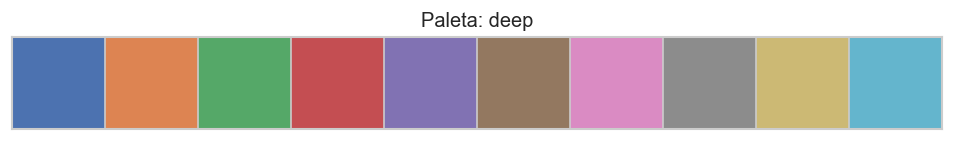

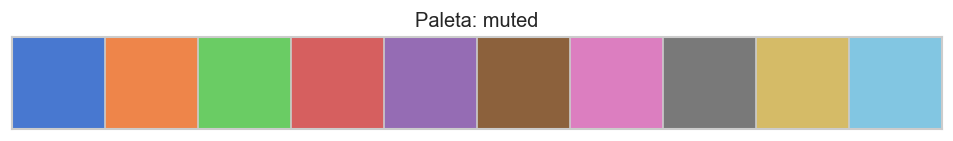

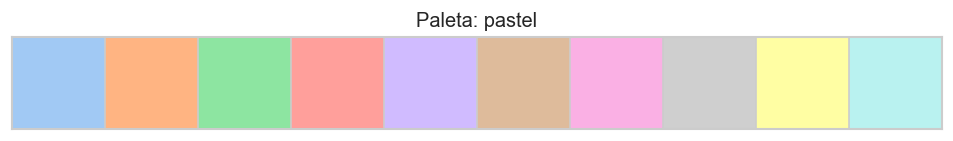

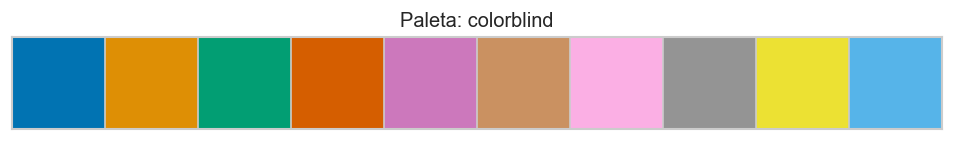

In [69]:
# Comparación rápida de paletas comunes.
# deep/muted/pastel: categorías generales.
# colorblind: opción más accesible cuando se quiere reducir dependencia de rojo-verde.

paletas = ["deep", "muted", "pastel", "colorblind"]

for paleta in paletas:
    sns.palplot(sns.color_palette(paleta))
    plt.title(f"Paleta: {paleta}")
    plt.show()

## 2. Distribuciones

Preguntas típicas:

- ¿Cómo se distribuye la prima?
- ¿Existen colas largas?
- ¿Qué ramo tiene mayor dispersión?
- ¿El promedio representa bien la cartera?

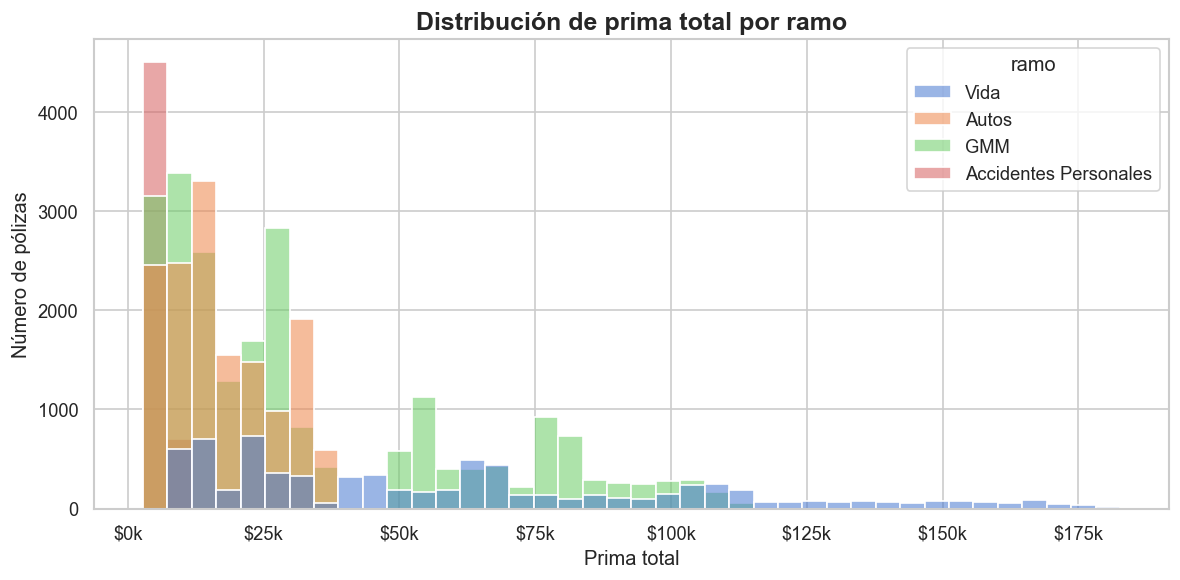

In [70]:
# Histograma de prima total por ramo.
# bins=40 controla cuántos intervalos se usan para contar pólizas.
# hue="ramo" separa visualmente la distribución de cada ramo.
# alpha=0.55 agrega transparencia para que las distribuciones superpuestas se distingan mejor.

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df,
    x="prima_total",
    hue="ramo",
    bins=40,
    alpha=0.55,
    ax=ax
)

ax.set_title("Distribución de prima total por ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Prima total")
ax.set_ylabel("Número de pólizas")
ax.xaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

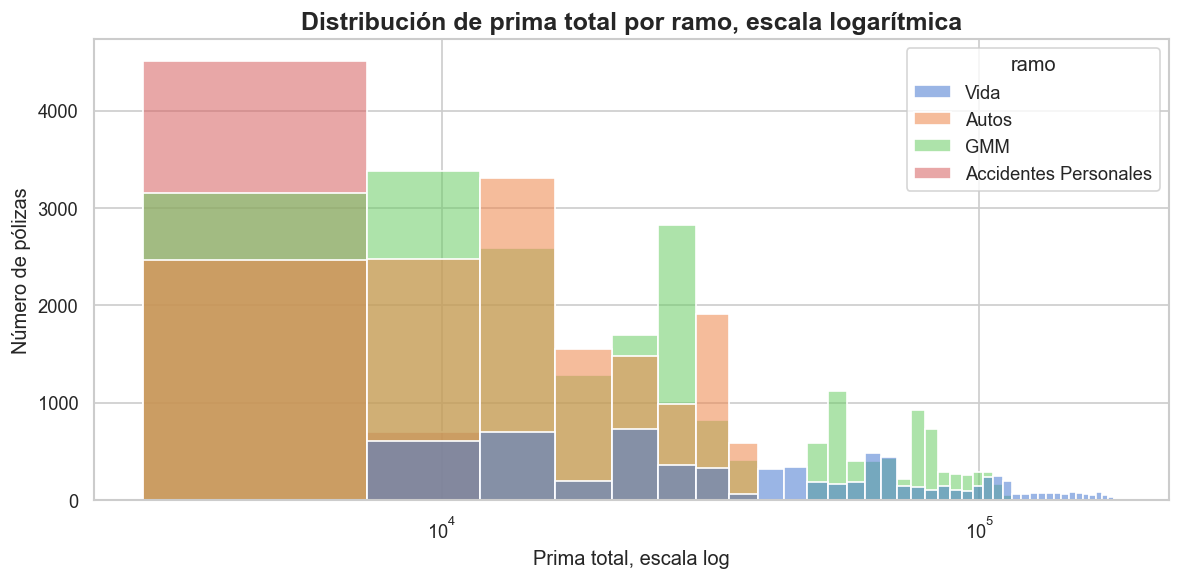

In [71]:
# Si la distribución tiene cola larga, una escala logarítmica puede ayudar.
# Importante: no usar escala logarítmica sin explicarla al público.

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df[df["prima_total"] > 0],
    x="prima_total",
    hue="ramo",
    bins=40,
    alpha=0.55,
    ax=ax
)

ax.set_xscale("log")
ax.set_title("Distribución de prima total por ramo, escala logarítmica", fontsize=15, fontweight="bold")
ax.set_xlabel("Prima total, escala log")
ax.set_ylabel("Número de pólizas")

plt.tight_layout()
plt.show()

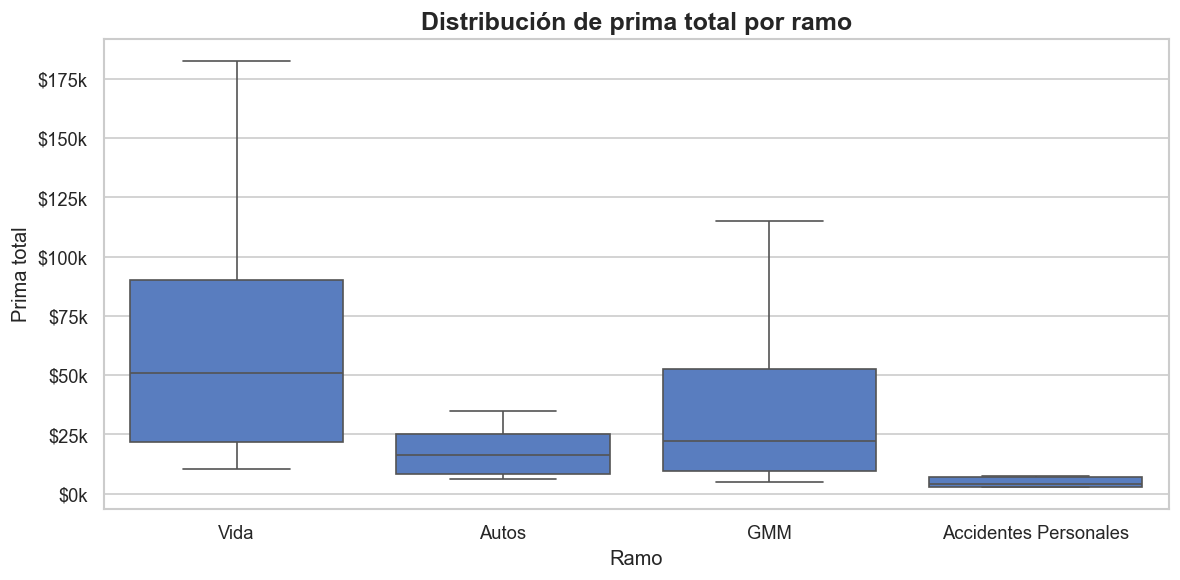

In [72]:
# Boxplot por ramo.
# La caja muestra el rango intercuartílico; la línea central es la mediana.
# Es útil para comparar dispersión y valores extremos entre ramos.

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="ramo",
    y="prima_total",
    color=sns.color_palette()[0],
    ax=ax
)

ax.set_title("Distribución de prima total por ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Ramo")
ax.set_ylabel("Prima total")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

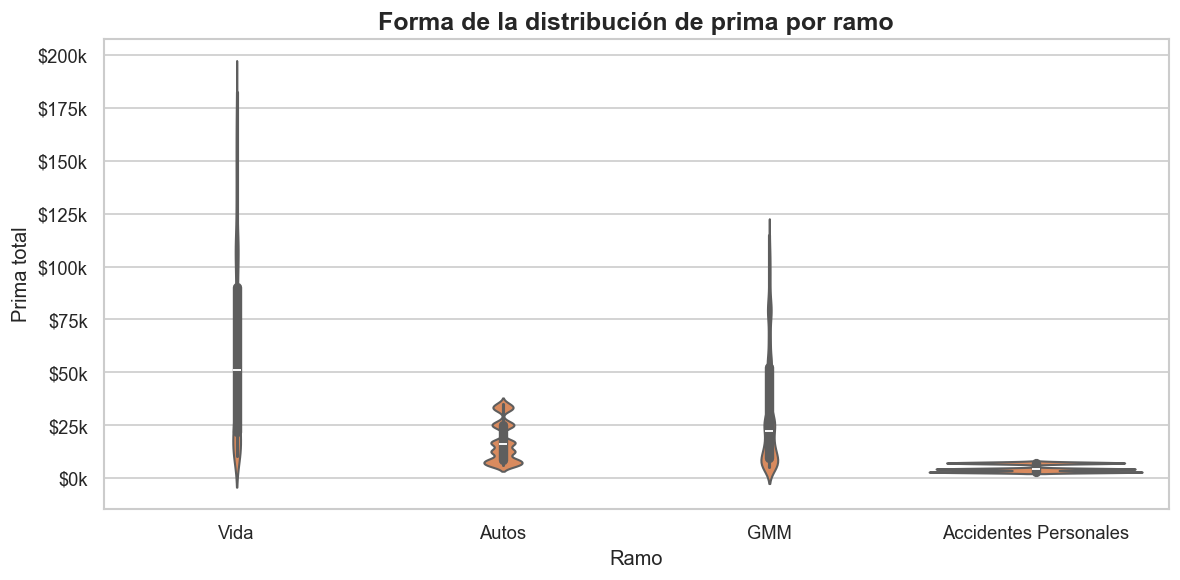

In [73]:
# Violinplot por ramo.
# A diferencia del boxplot, muestra la forma de la distribución.
# inner="box" conserva una referencia de mediana y cuartiles dentro del violín.

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df,
    x="ramo",
    y="prima_total",
    inner="box",
    color=sns.color_palette()[1],
    ax=ax
)

ax.set_title("Forma de la distribución de prima por ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Ramo")
ax.set_ylabel("Prima total")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

## 3. Comparaciones categóricas

Preguntas típicas:

- ¿Qué niveles de riesgo dominan la cartera?
- ¿Qué estados concentran prima?
- ¿Qué ramo tiene mayor prima promedio?
- ¿La composición cambia por grupo de edad?

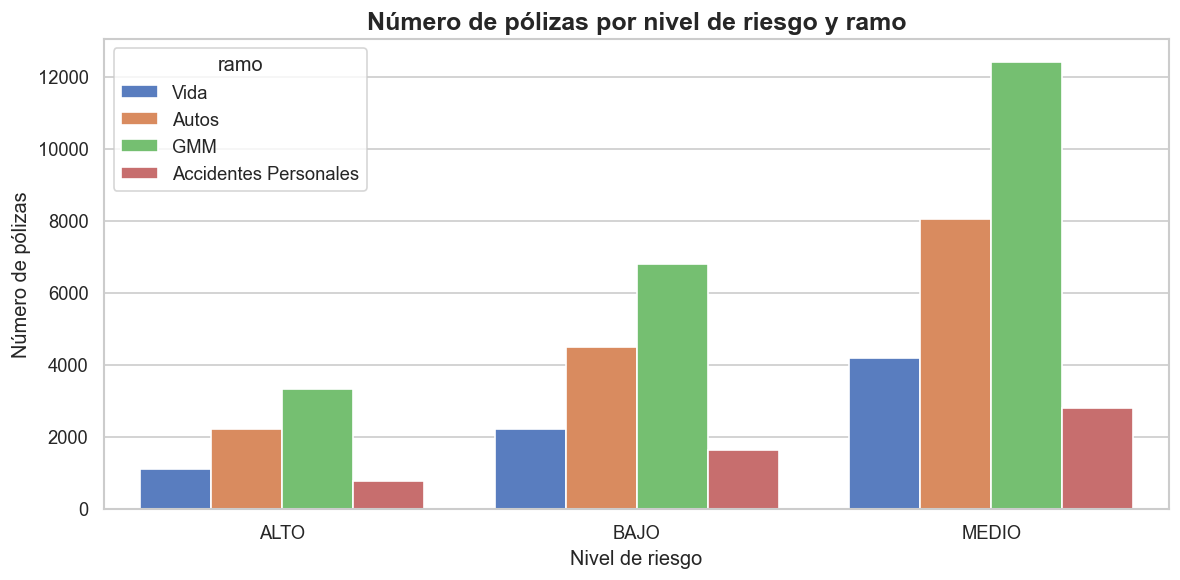

In [74]:
# Countplot: cuenta registros por categoría.
# Es adecuado cuando la pregunta es de frecuencia o composición.

fig, ax = plt.subplots(figsize=(10, 5))

orden_riesgo = None
if hasattr(df["nivel_riesgo"], "cat"):
    orden_riesgo = df["nivel_riesgo"].cat.categories.tolist()

sns.countplot(
    data=df,
    x="nivel_riesgo",
    hue="ramo",
    order=orden_riesgo,
    ax=ax
)

ax.set_title("Número de pólizas por nivel de riesgo y ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Nivel de riesgo")
ax.set_ylabel("Número de pólizas")

plt.tight_layout()
plt.show()

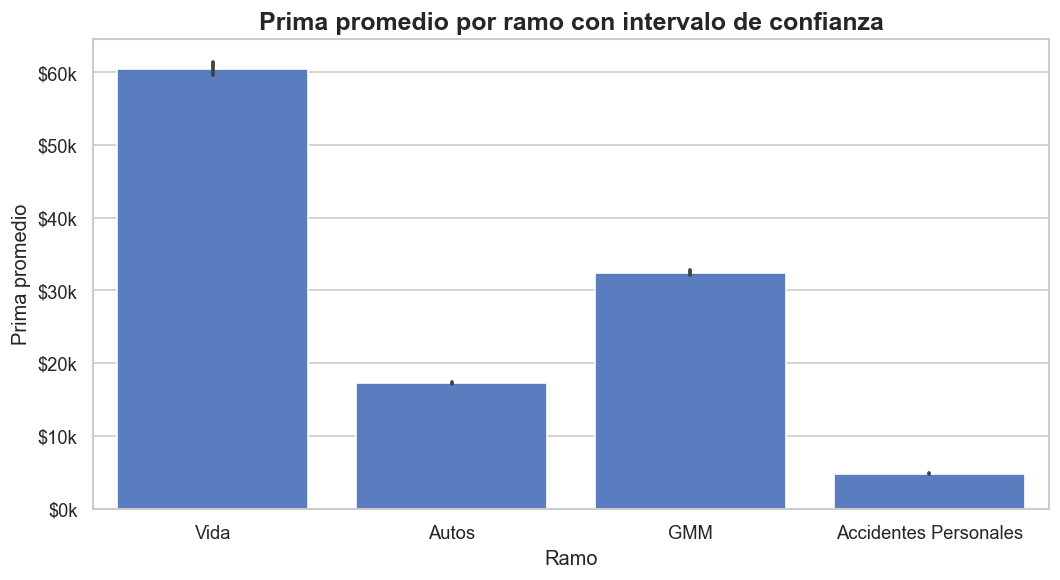

In [75]:
# Barplot: calcula un estimador sobre una variable numérica.
# En este caso, estima la prima promedio por ramo con intervalo de confianza.

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=df,
    x="ramo",
    y="prima_total",
    estimator="mean",
    errorbar="ci",
    color=sns.color_palette()[0],
    ax=ax
)

ax.set_title("Prima promedio por ramo con intervalo de confianza", fontsize=15, fontweight="bold")
ax.set_xlabel("Ramo")
ax.set_ylabel("Prima promedio")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

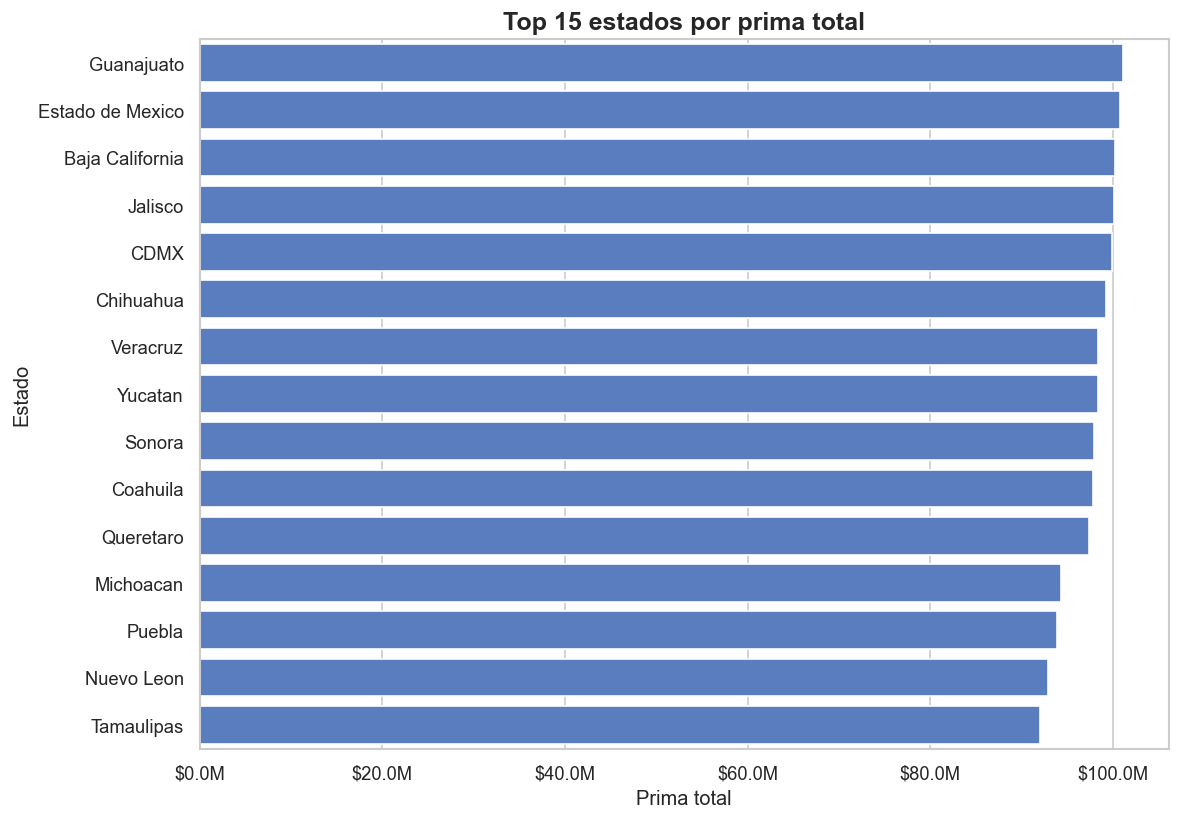

In [76]:
# Barras horizontales: recomendadas cuando hay muchas categorías.

prima_estado = (
    df.groupby("estado", as_index=False, observed=False)["prima_total"]
      .sum()
      .sort_values("prima_total", ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=prima_estado,
    y="estado",
    x="prima_total",
    color=sns.color_palette()[0],
    ax=ax
)

ax.set_title("Top 15 estados por prima total", fontsize=15, fontweight="bold")
ax.set_xlabel("Prima total")
ax.set_ylabel("Estado")
ax.xaxis.set_major_formatter(FuncFormatter(formato_millones))

plt.tight_layout()
plt.show()

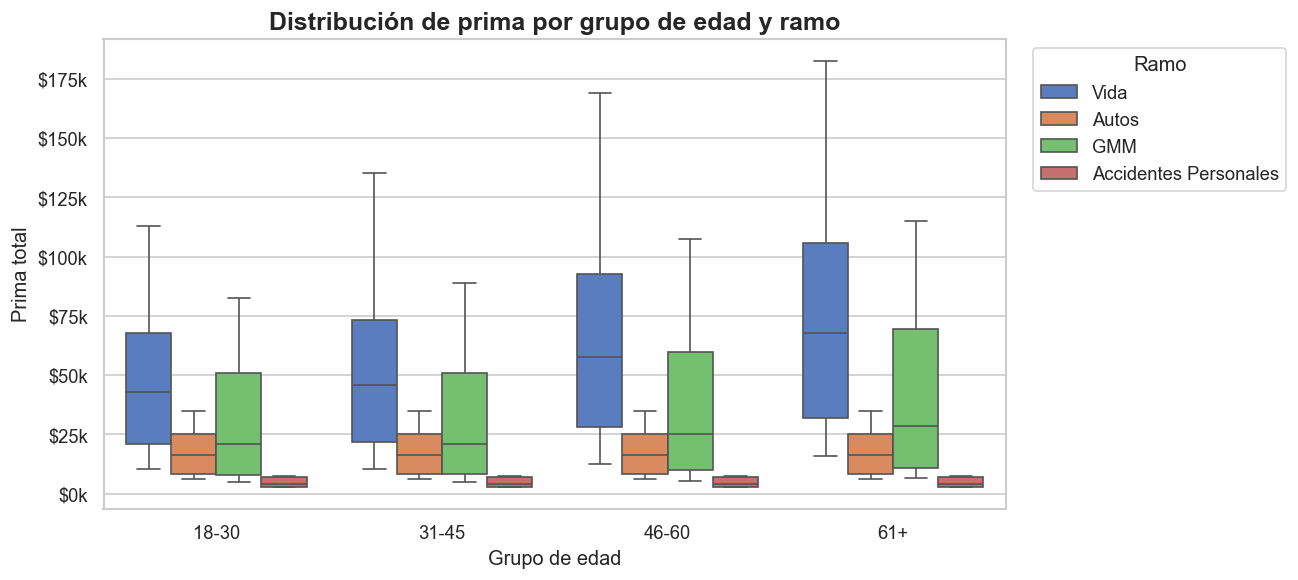

In [77]:
# Comparación por grupo de edad y ramo.
# Boxplot con hue permite comparar distribuciones, no solo promedios.

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(
    data=df,
    x="g_edad",
    y="prima_total",
    hue="ramo",
    ax=ax
)

ax.set_title("Distribución de prima por grupo de edad y ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Grupo de edad")
ax.set_ylabel("Prima total")
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))
ax.legend(title="Ramo", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 4. Relaciones y correlaciones

Preguntas típicas:

- ¿Existe relación entre prima y monto pagado?
- ¿Hay variables numéricas asociadas con `loss_ratio`?
- ¿Qué patrones aparecen por ramo?

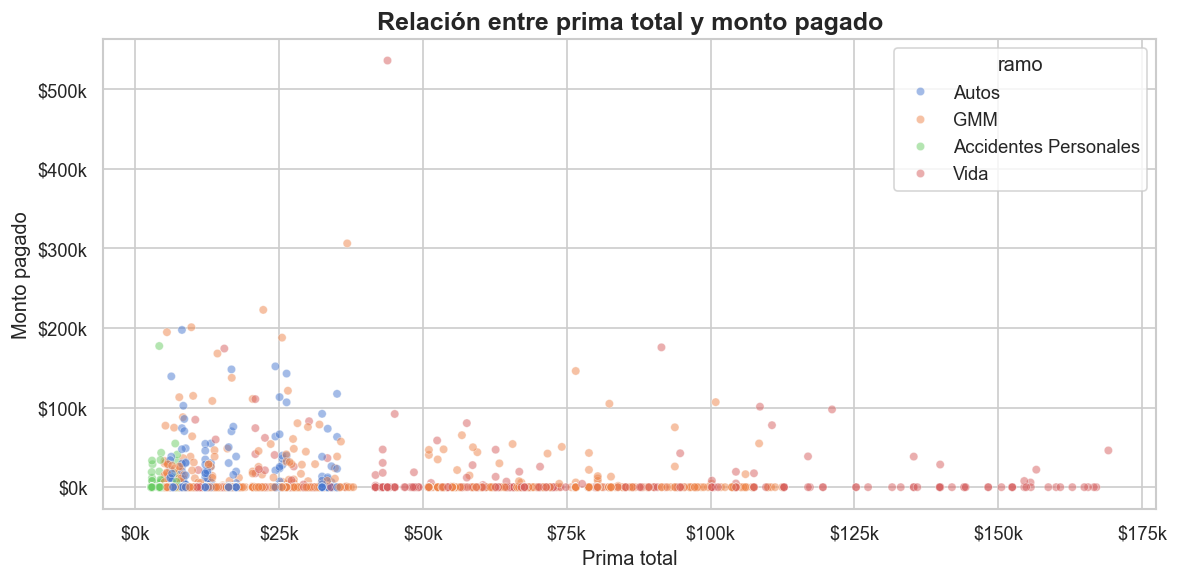

In [78]:
# Scatterplot con muestra para evitar saturación visual.
# Tomamos máximo 2,500 registros: suficientes para ver patrones sin sobrecargar la gráfica.
# random_state=123 hace que la muestra sea reproducible.

muestra = df.sample(min(2500, len(df)), random_state=123)

fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=muestra,
    x="prima_total",
    y="monto_pagado",
    hue="ramo",
    alpha=0.5,  # Transparencia para mostrar densidad cuando hay puntos encimados.
    s=25,       # Tamaño de cada punto.
    ax=ax
)

ax.set_title("Relación entre prima total y monto pagado", fontsize=15, fontweight="bold")
ax.set_xlabel("Prima total")
ax.set_ylabel("Monto pagado")
ax.xaxis.set_major_formatter(FuncFormatter(formato_miles))
ax.yaxis.set_major_formatter(FuncFormatter(formato_miles))

plt.tight_layout()
plt.show()

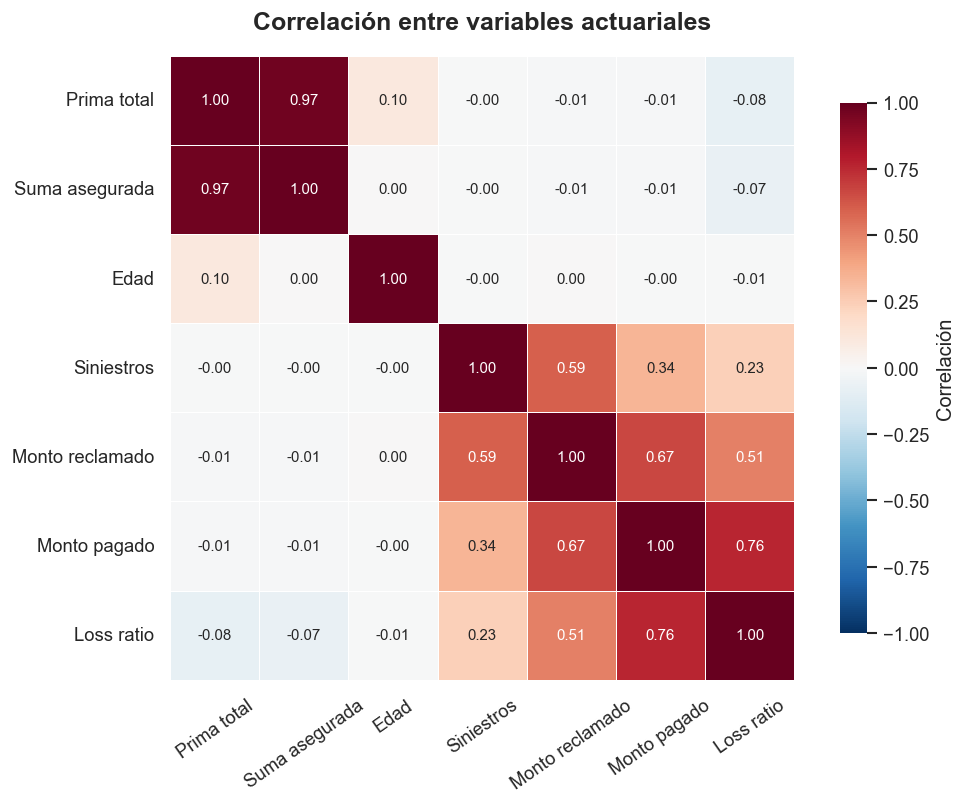

In [79]:
# Heatmap de correlación entre variables numéricas relevantes.
# Advertencia didáctica: correlación no implica causalidad.
# La correlación mide asociación lineal entre -1 y 1:
# - valores cercanos a 1 indican relación positiva fuerte;
# - valores cercanos a -1 indican relación negativa fuerte;
# - valores cercanos a 0 indican poca relación lineal.

cols_num = [
    "prima_total",
    "suma_asegurada",
    "edad",
    "n_siniestros",
    "monto_reclamado",
    "monto_pagado",
    "loss_ratio",
    "comision_est"
]

# Conservamos solo columnas existentes para que el notebook no falle si cambia la tabla.
cols_num = [c for c in cols_num if c in df.columns]
corr = df[cols_num].corr(numeric_only=True)

# Renombramos solo para visualización; los datos originales no cambian.
# Esto evita que etiquetas largas como monto_reclamado o suma_asegurada se corten.
etiquetas_corr = {
    "prima_total": "Prima total",
    "suma_asegurada": "Suma asegurada",
    "edad": "Edad",
    "n_siniestros": "Siniestros",
    "monto_reclamado": "Monto reclamado",
    "monto_pagado": "Monto pagado",
    "loss_ratio": "Loss ratio",
    "comision_est": "Comisión estimada"
}

corr_visual = corr.rename(index=etiquetas_corr, columns=etiquetas_corr)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    corr_visual,
    annot=True,        # Muestra el coeficiente dentro de cada celda.
    fmt=".2f",        # Dos decimales para facilitar lectura.
    cmap="RdBu_r",    # Azul/rojo divergente: útil para negativos vs positivos.
    center=0,          # El color neutro representa correlación cero.
    vmin=-1,
    vmax=1,
    square=True,       # Mantiene celdas cuadradas para evitar deformación visual.
    linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"label": "Correlación", "shrink": 0.85},
    ax=ax
)

ax.set_title("Correlación entre variables actuariales", fontsize=15, fontweight="bold", pad=16)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)

# Ajustamos márgenes para que no se corten etiquetas ni colorbar en el notebook.
plt.subplots_adjust(left=0.22, bottom=0.25, right=0.92, top=0.90)
plt.show()

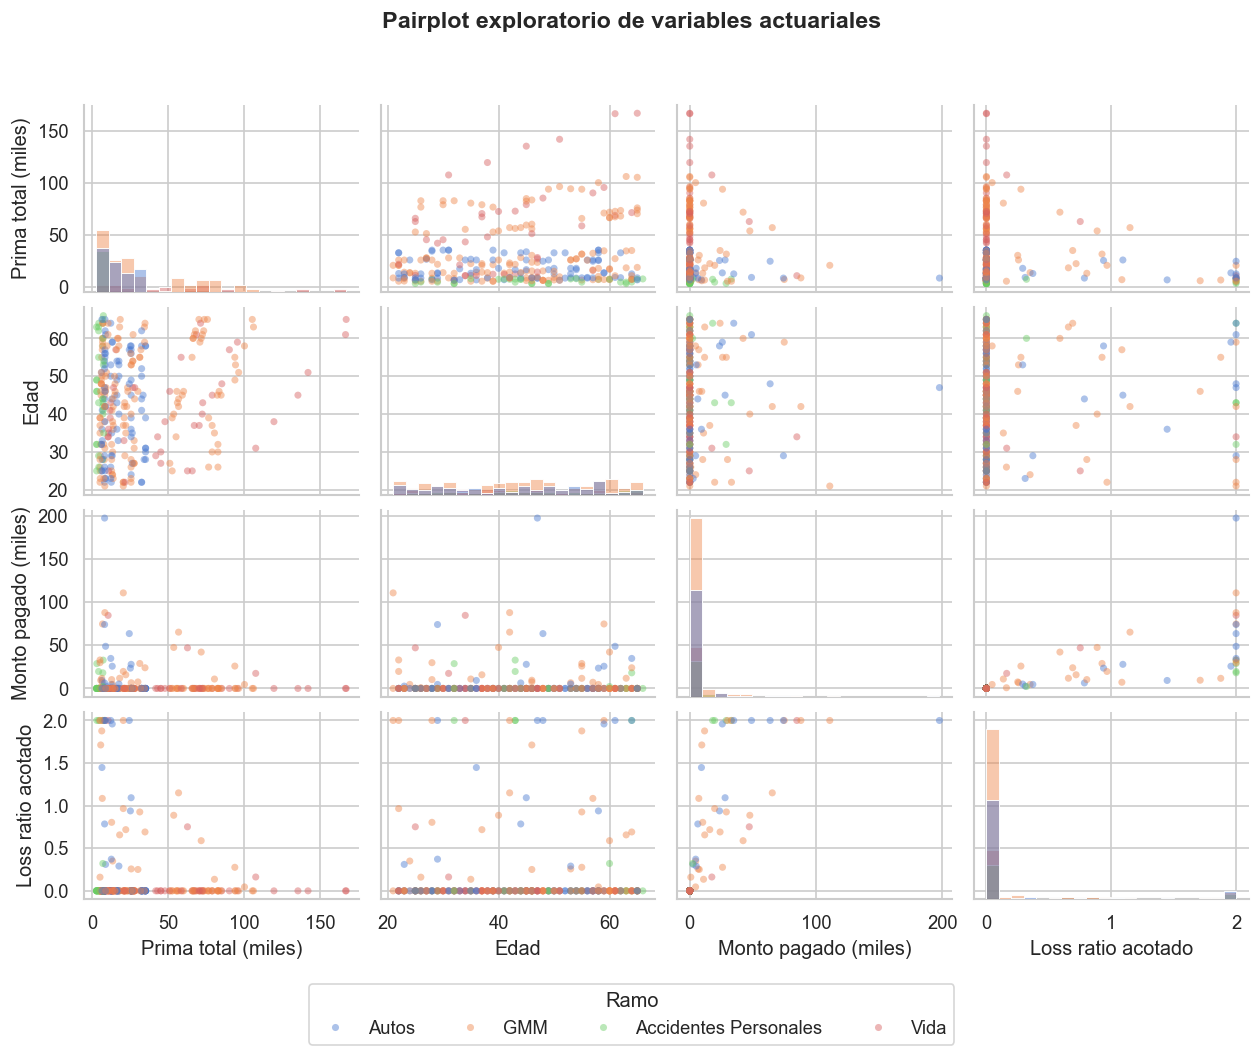

In [80]:
# Pairplot: útil para exploración, no necesariamente para reporte final.
# Por desempeño, queda como celda opcional. Cambia EJECUTAR_PAIRPLOT a True si quieres mostrarlo en clase.
# Nota: el pairplot original con corner=True dejaba un triángulo vacío grande.
# Aquí usamos la matriz completa y variables transformadas/acotadas para que la lectura sea más clara.

# Crear columnas faltantes si no existen

if 'monto_pagado' not in df.columns:
    df['monto_pagado'] = 0

if 'loss_ratio' not in df.columns:
    df['loss_ratio'] = (
        df['monto_pagado'] /
        df['prima_total']
    ).replace([np.inf, -np.inf], np.nan)


EJECUTAR_PAIRPLOT = True

if EJECUTAR_PAIRPLOT:
    cols_pair = ["prima_total", "edad", "monto_pagado", "loss_ratio", "ramo"]
    cols_pair = [c for c in cols_pair if c in df.columns]

    muestra_pair = df[cols_pair].dropna().sample(min(300, len(df)), random_state=123).copy()

    # Pasamos montos a miles para que los ejes sean más compactos.
    # Acotamos loss_ratio a 200% para que pocos valores extremos no compriman el resto.
    muestra_pair["Prima total (miles)"] = muestra_pair["prima_total"] / 1_000
    muestra_pair["Monto pagado (miles)"] = muestra_pair["monto_pagado"] / 1_000
    muestra_pair["Loss ratio acotado"] = muestra_pair["loss_ratio"].clip(0, 2)
    muestra_pair = muestra_pair.rename(columns={"edad": "Edad", "ramo": "Ramo"})

    g = sns.pairplot(
        muestra_pair,
        vars=["Prima total (miles)", "Edad", "Monto pagado (miles)", "Loss ratio acotado"],
        hue="Ramo",
        diag_kind="hist",
        corner=False,
        height=2.15,
        aspect=1,
        plot_kws={"alpha": 0.45, "s": 18, "edgecolor": "none"},
        diag_kws={"alpha": 0.45, "bins": 20}
    )

    g.fig.suptitle("Pairplot exploratorio de variables actuariales", y=1.02, fontsize=14, fontweight="bold")

    # Reubicamos la leyenda abajo para que no tape ninguna subgráfica.
    if g._legend is not None:
        handles = g._legend.legend_handles
        labels = [text.get_text() for text in g._legend.texts]
        g._legend.remove()
        g.fig.legend(
            handles,
            labels,
            title="Ramo",
            loc="lower center",
            ncol=4,
            bbox_to_anchor=(0.5, 0.01),
            frameon=True
        )

    g.fig.subplots_adjust(top=0.93, bottom=0.16, right=0.98, wspace=0.08, hspace=0.08)
    plt.show()
else:
    print("Pairplot omitido por desempeño. Cambia EJECUTAR_PAIRPLOT = True para ejecutarlo.")

## 5. Tendencias y narrativa visual

Una gráfica ejecutiva no solo muestra datos: comunica un hallazgo. El título debe ayudar a interpretar, no solo nombrar variables.

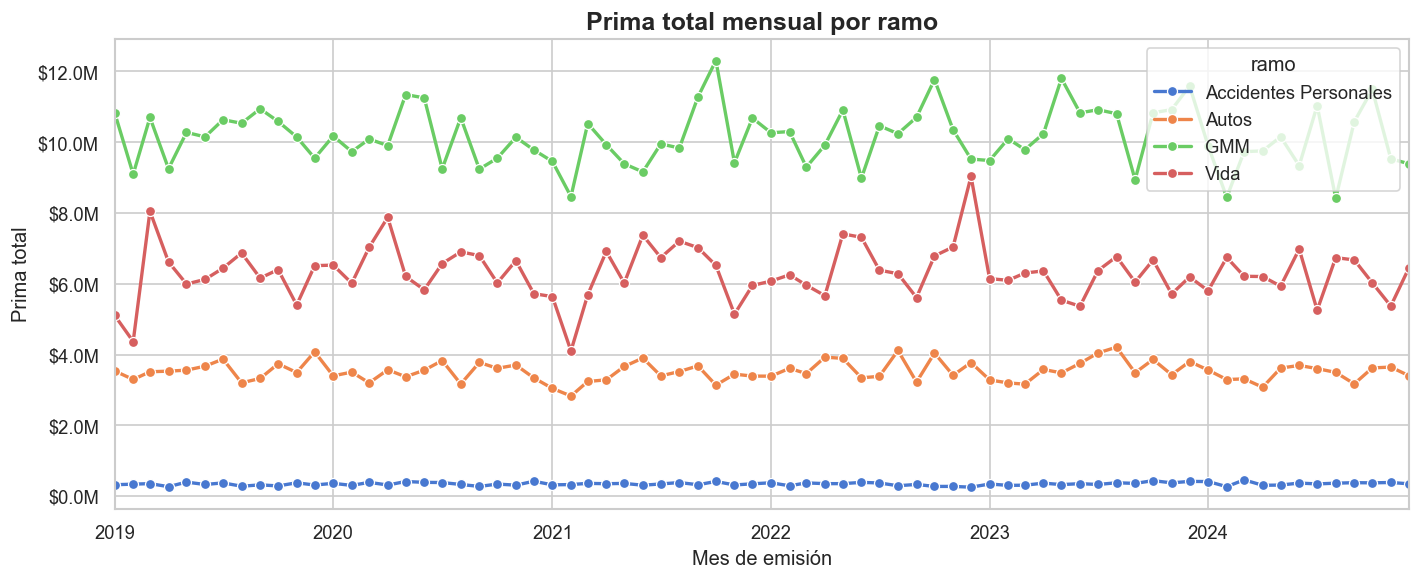

In [81]:
# Tendencia mensual por ramo.
# Agrupamos por mes y ramo para obtener la prima emitida mensual de cada línea de negocio.
# Después convertimos mes a fecha real para que el eje X sea temporal y no categórico.

por_mes = (
    df.groupby(["mes", "ramo"], as_index=False, observed=False)["prima_total"]
      .sum()
      .sort_values("mes")
)
por_mes["mes_fecha"] = pd.to_datetime(por_mes["mes"])

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=por_mes,
    x="mes_fecha",
    y="prima_total",
    hue="ramo",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title("Prima total mensual por ramo", fontsize=15, fontweight="bold")
ax.set_xlabel("Mes de emisión")
ax.set_ylabel("Prima total")
ax.set_xlim(por_mes["mes_fecha"].min(), por_mes["mes_fecha"].max())
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

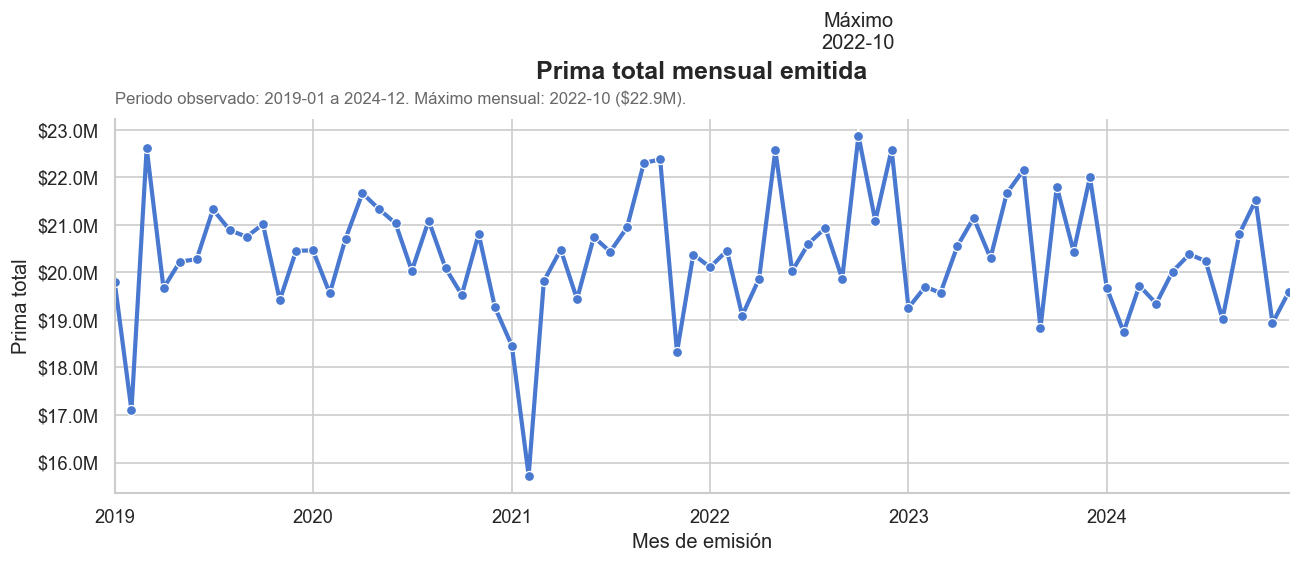

In [82]:
# Versión ejecutiva: una sola serie, título descriptivo y subtítulo interpretativo.
# Esta versión reduce la gráfica a la prima total mensual para comunicar un mensaje principal.
# Criterio editorial: el título describe la métrica; el subtítulo contiene el periodo y el hallazgo.

por_mes_total = (
    df.groupby("mes", as_index=False)["prima_total"]
      .sum()
      .sort_values("mes")
)
por_mes_total["mes_fecha"] = pd.to_datetime(por_mes_total["mes"])

# Periodo observado: se calcula desde los datos para evitar escribir fechas manualmente.
periodo_inicio = por_mes_total["mes"].min()
periodo_fin = por_mes_total["mes"].max()

# Identificamos el punto máximo para mencionarlo en el subtítulo y anotarlo en la línea.
idx_max = por_mes_total["prima_total"].idxmax()
mes_max = por_mes_total.loc[idx_max, "mes"]
mes_max_fecha = por_mes_total.loc[idx_max, "mes_fecha"]
prima_max = por_mes_total.loc[idx_max, "prima_total"]
prima_max_texto = f"${prima_max/1_000_000:,.1f}M"

fig, ax = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=por_mes_total,
    x="mes_fecha",
    y="prima_total",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title("Prima total mensual emitida", fontsize=15, fontweight="bold", pad=24)
ax.text(
    0,
    1.04,
    f"Periodo observado: {periodo_inicio} a {periodo_fin}. Máximo mensual: {mes_max} ({prima_max_texto}).",
    transform=ax.transAxes,
    fontsize=10,
    color="dimgray",
    ha="left"
)

ax.set_xlabel("Mes de emisión")
ax.set_ylabel("Prima total")
ax.set_xlim(por_mes_total["mes_fecha"].min(), por_mes_total["mes_fecha"].max())
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.tick_params(axis="x", rotation=0)

ax.annotate(
    f"Máximo\n{mes_max}",
    xy=(mes_max_fecha, prima_max),
    xytext=(mes_max_fecha, prima_max * 1.08),
    ha="center",
    arrowprops={"arrowstyle": "->"}
)

sns.despine()
plt.tight_layout()
plt.show()

## 5.1. Loss ratio calculado por ramo y mes de inicio de vigencia

El campo `loss_ratio` que viene en la base puede ser útil como referencia operativa, pero para una lectura de negocio conviene calcularlo a nivel agregado.

Aquí construiremos una tabla nueva por `ramo` y `mes_inicio_vigencia` usando:

$$	ext{loss ratio calculado} = 
rac{\sum 	ext{monto pagado}}{\sum 	ext{prima total}}$$

Este cálculo evita interpretar el loss ratio póliza por póliza, donde muchos registros pueden tener cero siniestros o valores extremos.

In [83]:
# Construimos una tabla agregada para calcular loss ratio por ramo y mes de inicio de vigencia.
# Usamos fecha_inicio_vigencia porque la pregunta pide el mes de inicio de vigencia, no el mes de emisión.
# La prima y el monto pagado se agregan primero; después se calcula el cociente.

loss_ratio_ramo_mes = (
    df.assign(
        mes_inicio_vigencia=df["fecha_inicio_vigencia"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby(["mes_inicio_vigencia", "ramo"], as_index=False, observed=False)
    .agg(
        polizas=("id_poliza", "count"),
        prima_total=("prima_total", "sum"),
        monto_pagado=("monto_pagado", "sum")
    )
    .sort_values(["mes_inicio_vigencia", "ramo"])
)

loss_ratio_ramo_mes["loss_ratio_calculado"] = (
    loss_ratio_ramo_mes["monto_pagado"]
    / loss_ratio_ramo_mes["prima_total"].replace(0, np.nan)
)

loss_ratio_ramo_mes.head(12).style.format({
    "mes_inicio_vigencia": "{:%Y-%m}",
    "polizas": "{:,.0f}",
    "prima_total": "${:,.0f}",
    "monto_pagado": "${:,.0f}",
    "loss_ratio_calculado": "{:.1%}"
})

,mes_inicio_vigencia,ramo,polizas,prima_total,monto_pagado,loss_ratio_calculado
0,2019-01,Accidentes Personales,68,"$323,041","$212,306",65.7%
1,2019-01,Autos,206,"$3,538,513","$918,589",26.0%
2,2019-01,GMM,350,"$10,838,406","$1,611,703",14.9%
3,2019-01,Vida,91,"$5,109,288","$509,738",10.0%
4,2019-02,Accidentes Personales,67,"$339,119","$351,779",103.7%
5,2019-02,Autos,185,"$3,296,618","$446,263",13.5%
6,2019-02,GMM,284,"$9,095,139","$837,359",9.2%
7,2019-02,Vida,77,"$4,369,850","$177,556",4.1%
8,2019-03,Accidentes Personales,78,"$354,890","$72,713",20.5%
9,2019-03,Autos,201,"$3,514,803","$487,732",13.9%


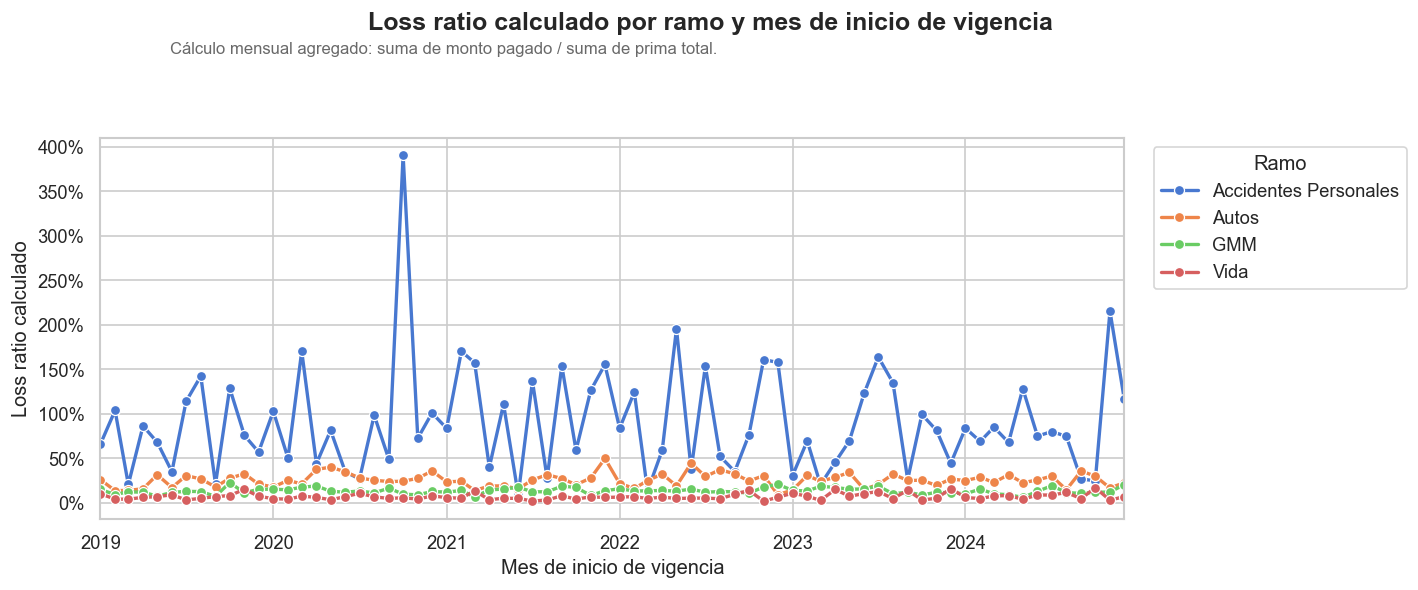

In [84]:
# Graficamos el loss ratio calculado por ramo a través del tiempo.
# Cada punto representa el cociente agregado del mes y ramo correspondiente.

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=loss_ratio_ramo_mes,
    x="mes_inicio_vigencia",
    y="loss_ratio_calculado",
    hue="ramo",
    marker="o",
    linewidth=2,
    ax=ax
)

fig.suptitle(
    "Loss ratio calculado por ramo y mes de inicio de vigencia",
    fontsize=15,
    fontweight="bold",
    y=0.98
)
fig.text(
    0.125,
    0.91,
    "Cálculo mensual agregado: suma de monto pagado / suma de prima total.",
    fontsize=10,
    color="dimgray",
    ha="left"
)

ax.set_xlabel("Mes de inicio de vigencia")
ax.set_ylabel("Loss ratio calculado")
ax.set_xlim(
    loss_ratio_ramo_mes["mes_inicio_vigencia"].min(),
    loss_ratio_ramo_mes["mes_inicio_vigencia"].max()
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="Ramo", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

In [85]:
# Resumen por ramo para apoyar la interpretación.
# Calculamos un loss ratio global por ramo: suma total de monto pagado / suma total de prima.

resumen_loss_ratio_ramo = (
    loss_ratio_ramo_mes.groupby("ramo", as_index=False, observed=False)
      .agg(
          meses=("mes_inicio_vigencia", "nunique"),
          prima_total=("prima_total", "sum"),
          monto_pagado=("monto_pagado", "sum")
      )
)

resumen_loss_ratio_ramo["loss_ratio_global"] = (
    resumen_loss_ratio_ramo["monto_pagado"]
    / resumen_loss_ratio_ramo["prima_total"].replace(0, np.nan)
)

resumen_loss_ratio_ramo = resumen_loss_ratio_ramo.sort_values("loss_ratio_global", ascending=False)

resumen_loss_ratio_ramo.style.format({
    "meses": "{:,.0f}",
    "prima_total": "${:,.0f}",
    "monto_pagado": "${:,.0f}",
    "loss_ratio_global": "{:.1%}"
})

,ramo,meses,prima_total,monto_pagado,loss_ratio_global
0,Accidentes Personales,72,"$24,980,678","$22,311,397",89.3%
1,Autos,72,"$253,823,504","$64,499,502",25.4%
2,GMM,72,"$731,022,336","$96,912,286",13.3%
3,Vida,72,"$454,332,128","$30,878,141",6.8%


## 6. Ejercicio final

Construye una gráfica propia que responda una pregunta de negocio. Debe cumplir:

1. Título interpretativo.
2. Ejes claros y con unidades.
3. Categorías ordenadas cuando aplique.
4. Uso intencional del color.
5. Una conclusión escrita.

/var/folders/0x/kxtns7515ps4lbrgywb868nw0000gn/T/ipykernel_89191/1298637884.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


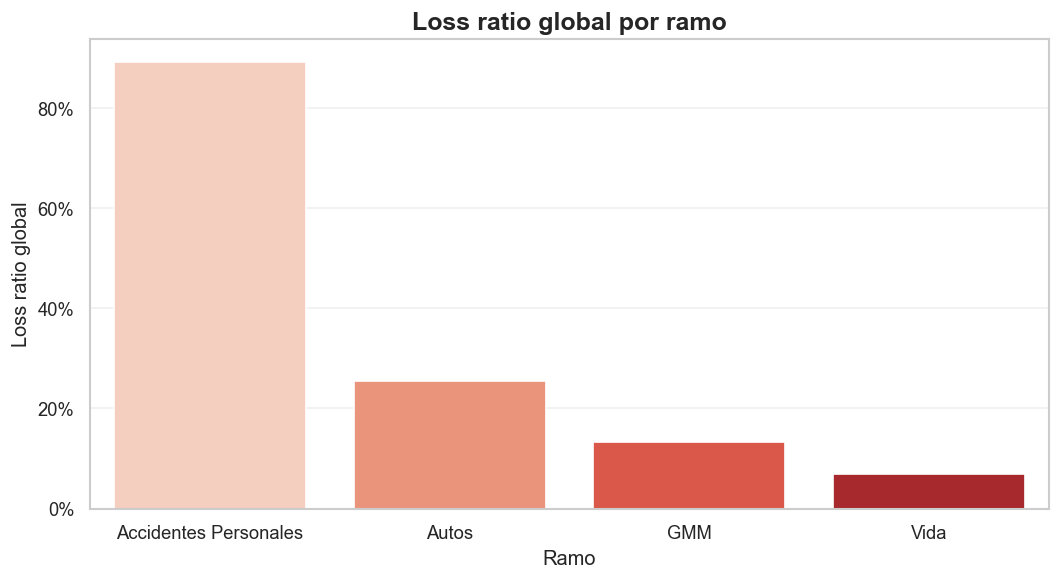

Conclusión: El ramo con mayor loss ratio global fue accidentes personales, lo que indica una mayor proporción de pagos por siniestros respecto a las primas cobradas. Esto puede representar mayor presión sobre la rentabilidad técnica del ramo.


In [89]:
# Plantilla para el ejercicio final.
# Pregunta sugerida: ¿qué ramos tienen mayor loss ratio global calculado?
# Usamos la tabla agregada loss_ratio_ramo_mes creada arriba, no el loss_ratio crudo por póliza.
# PercentFormatter(1.0) interpreta 1.0 como 100%.

# Ejercicio final
# Pregunta de negocio:
# ¿Qué ramos presentan mayor loss ratio global?

# Construimos tabla agregada
resumen_loss_ratio_ramo = (
    df.groupby("ramo", as_index=False)
      .agg(
          prima_total=("prima_total", "sum"),
          monto_pagado=("monto_pagado", "sum")
      )
)

# Loss ratio global
resumen_loss_ratio_ramo["loss_ratio_global"] = (
    resumen_loss_ratio_ramo["monto_pagado"] /
    resumen_loss_ratio_ramo["prima_total"]
)

# Ordenar de mayor a menor
resumen_loss_ratio_ramo = resumen_loss_ratio_ramo.sort_values(
    "loss_ratio_global",
    ascending=False
)

# Gráfica
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=resumen_loss_ratio_ramo,
    x="ramo",
    y="loss_ratio_global",
    palette="Reds",
    ax=ax
)

ax.set_title(
    "Loss ratio global por ramo",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Ramo")

ax.set_ylabel("Loss ratio global")

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.grid(axis="y", alpha=0.30)

plt.tight_layout()

plt.show()

# Conclusión
ramo_max = resumen_loss_ratio_ramo.iloc[0]["ramo"]

print(
    f"Conclusión: El ramo con mayor loss ratio global fue accidentes personales, "
    "lo que indica una mayor proporción de pagos por siniestros "
    "respecto a las primas cobradas. Esto puede representar "
    "mayor presión sobre la rentabilidad técnica del ramo."
)